In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "1796325046"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=[0, 1, 2, 4, 5, 6, 7,8, 9, 10, 11]).iloc[:, :]
df

,Model,Compression,Size (MB),ROC_AUC,PR_AUC,ROC_AUC.1,PR_AUC.1,ROC_AUC.2,PR_AUC.2,ROC_AUC.3,PR_AUC.3
0,pythia-70M,Original,281.731840,0.645490,0.60866,0.64906,0.61320,0.66505,0.62855,0.61867,0.56285
1,pythia-70M,8-bit,122.126910,0.645250,0.60859,0.64803,0.61204,0.66492,0.62869,0.61855,0.56315
2,pythia-70M,4-bit,113.771070,0.633570,0.60442,0.63208,0.60402,0.65657,0.62541,0.58659,0.54286
3,gptneo-125M,Original,500.846406,0.641278,0.60800,0.64276,0.60956,0.65977,0.62514,0.58146,0.55414
4,gptneo-125M,8-bit,165.882166,0.637613,0.60689,0.63975,0.60729,0.65722,0.62423,0.57208,0.54785
5,gptneo-125M,4-bit,128.428110,0.595357,0.58776,0.60668,0.59279,0.62578,0.60896,0.47033,0.48068
6,pythia-160M,Original,649.341190,0.657010,0.61645,0.65590,0.61574,0.67443,0.63549,0.63949,0.58167
7,pythia-160M,8-bit,240.116640,0.656575,0.61566,0.65523,0.61455,0.67410,0.63498,0.63815,0.58095
8,pythia-160M,4-bit,202.650480,0.644996,0.61117,0.64187,0.60902,0.66678,0.63265,0.59686,0.55090
9,codegen-350M-nl,Original,1426.904237,0.652362,0.61402,0.65353,0.61386,0.67010,0.63053,0.56309,0.55053


In [19]:
def genGraph(df, miaName):
    scoreName = df.columns[3].split(".")[0]
    # Extract unique model names
    models = df["Model"].unique()
    compressions = df["Compression"].unique()

    # Define bar width and colors
    bar_width = 0.2
    colors = ["blue", "green", "orange"]

    x = np.arange(len(models))  # X-axis positions

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot bar chart for model sizes
    for i, comp in enumerate(compressions):
        subset = df[df["Compression"] == comp]
        ax1.bar(x + i * bar_width, subset["Size (MB)"], width=bar_width, label=f"{comp} Model Size (MB)", alpha=0.7, color=colors[i])

    ax1.set_ylabel("Model Size (MB)")
    ax1.set_xticks(x + bar_width * 1.5)
    ax1.set_xticklabels(models, rotation=15)
    ax1.legend(loc="upper left")

    # Second y-axis for performance scores
    ax2 = ax1.twinx()

    # Plot line chart for performance
    for i, comp in enumerate(compressions):
        subset = df[df["Compression"] == comp]
        ax2.plot(x + i * bar_width, subset.iloc[:,3], marker="o", linestyle="-", label=f"{comp} {scoreName} ({miaName}) (%)", color=colors[i])

    ax2.set_ylabel(f"{scoreName} ({miaName}) (%)")
    # ax2.set_ylim(0.6, 0.7)
    ax2.legend(loc="center left", bbox_to_anchor=(0, 0.7))
    # ax2.legend(loc="upper right")

    plt.title(f"Comparison of Model Sizes and MIA ({miaName}) Across Compression Levels")
    # plt.savefig(f"./output/{scoreName}({miaName}).png", dpi=300, bbox_inches="tight")
    plt.show()

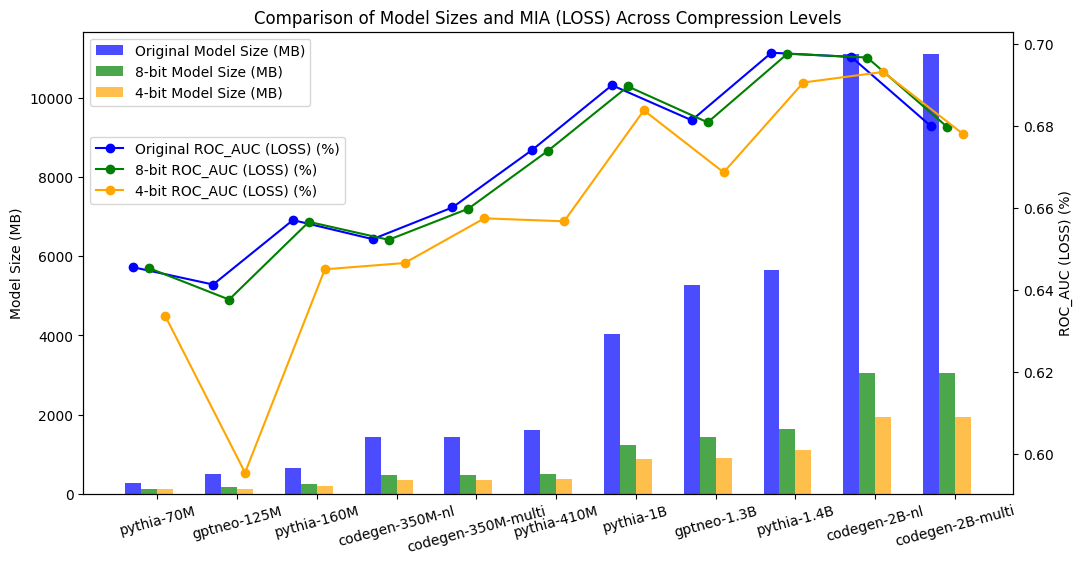

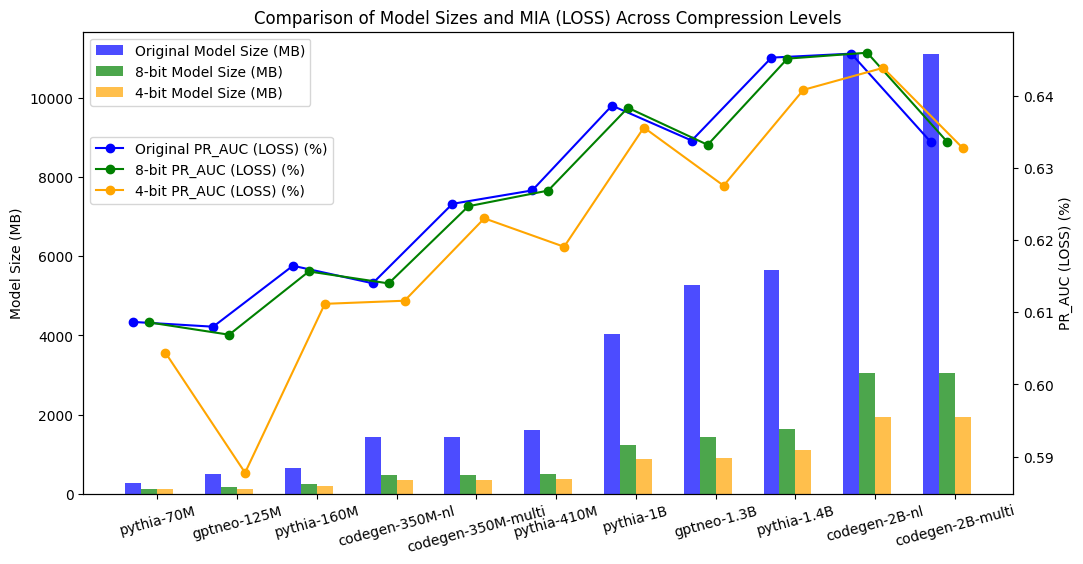

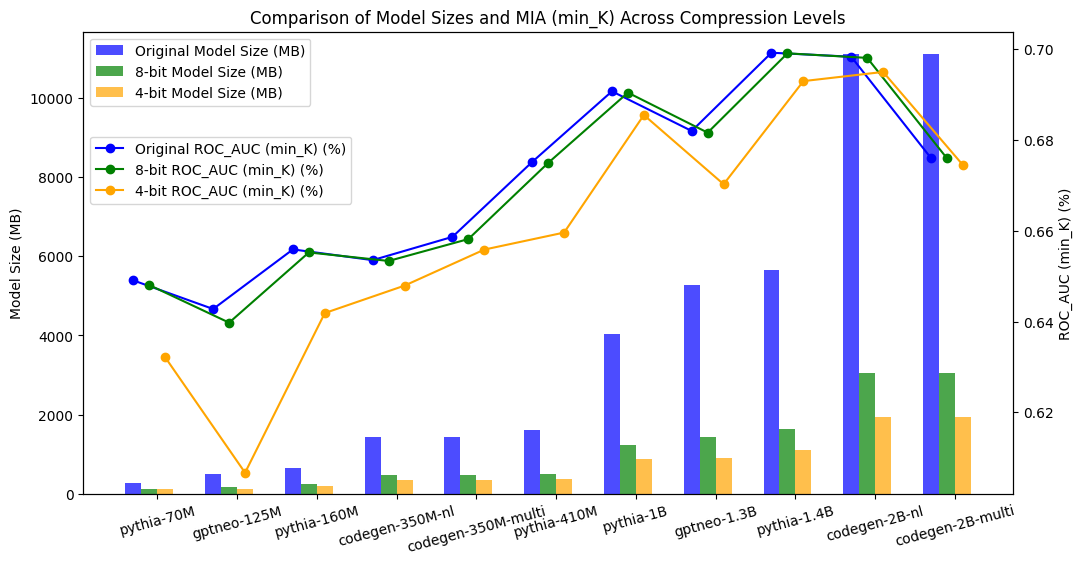

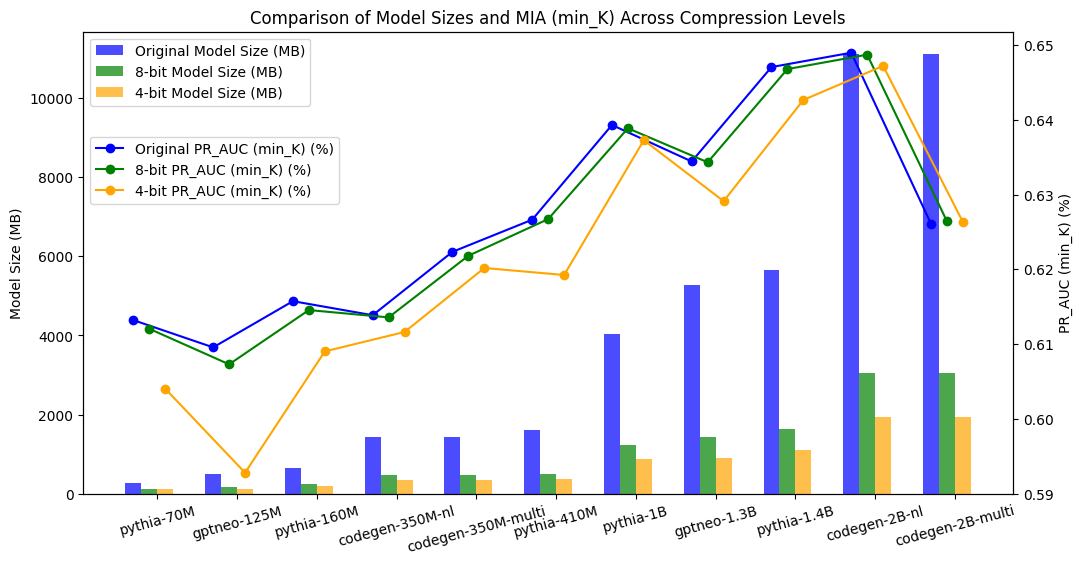

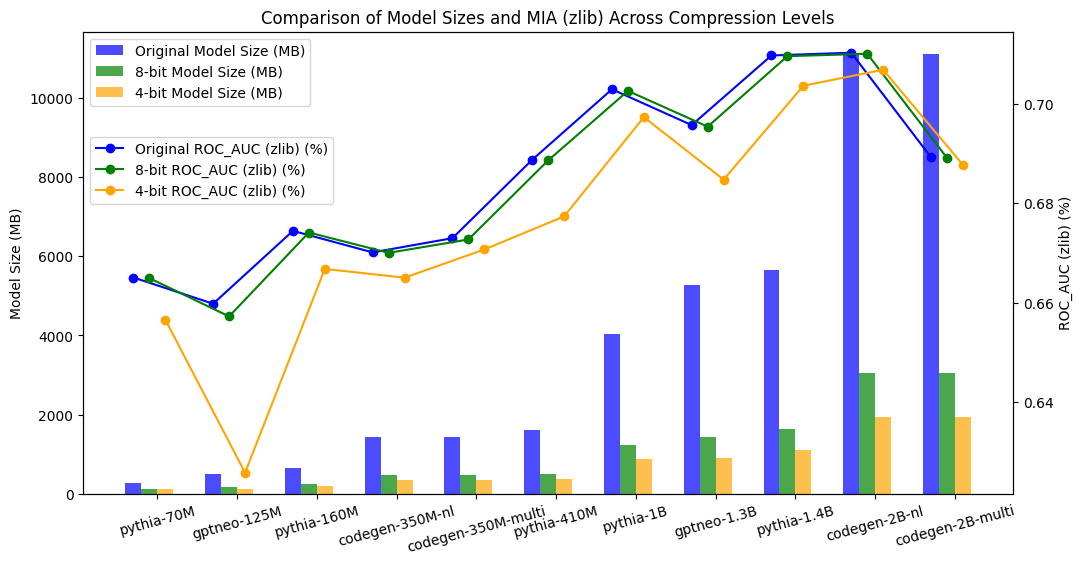

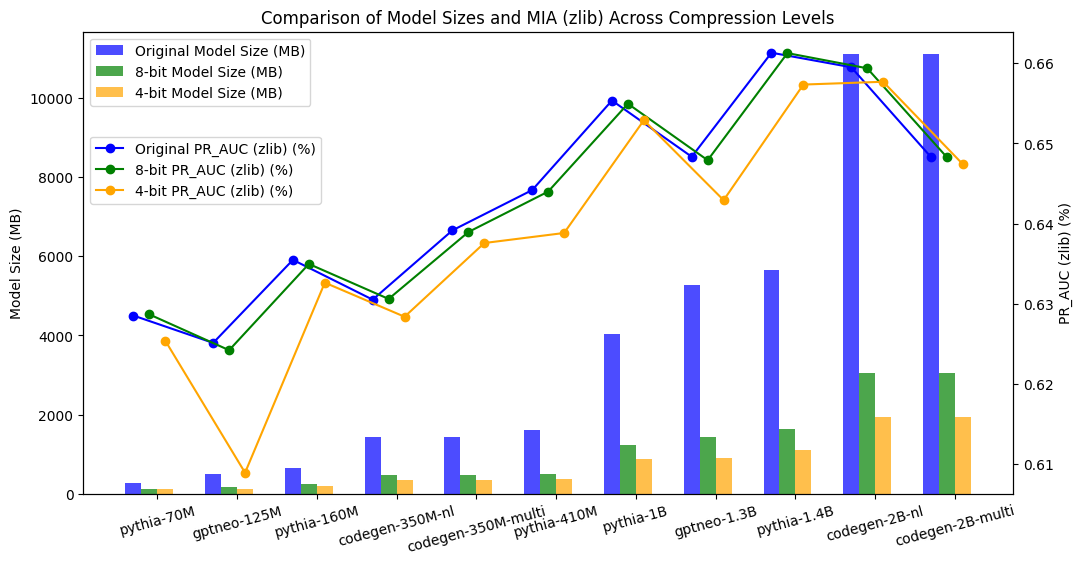

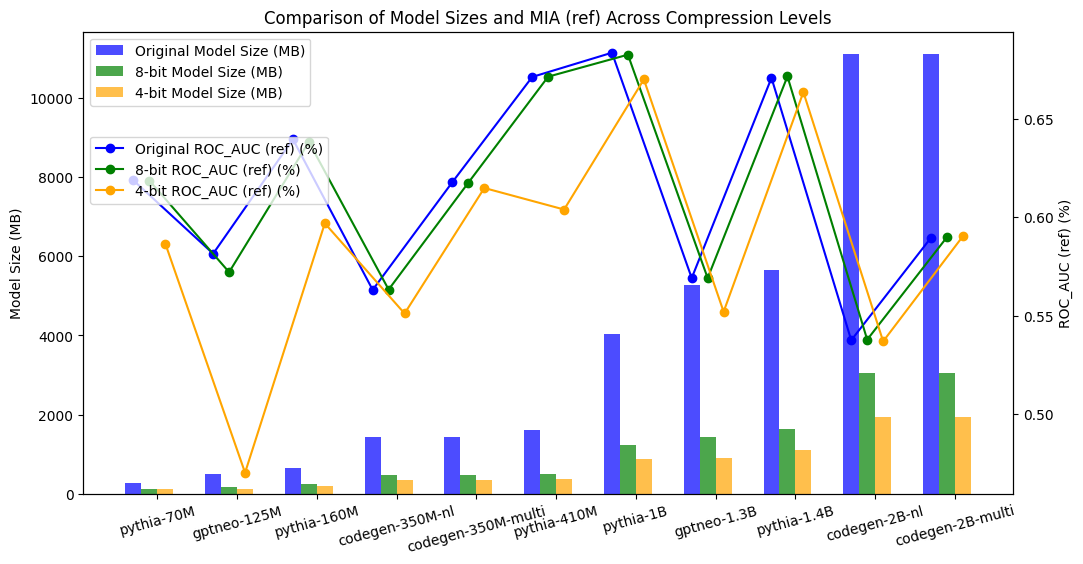

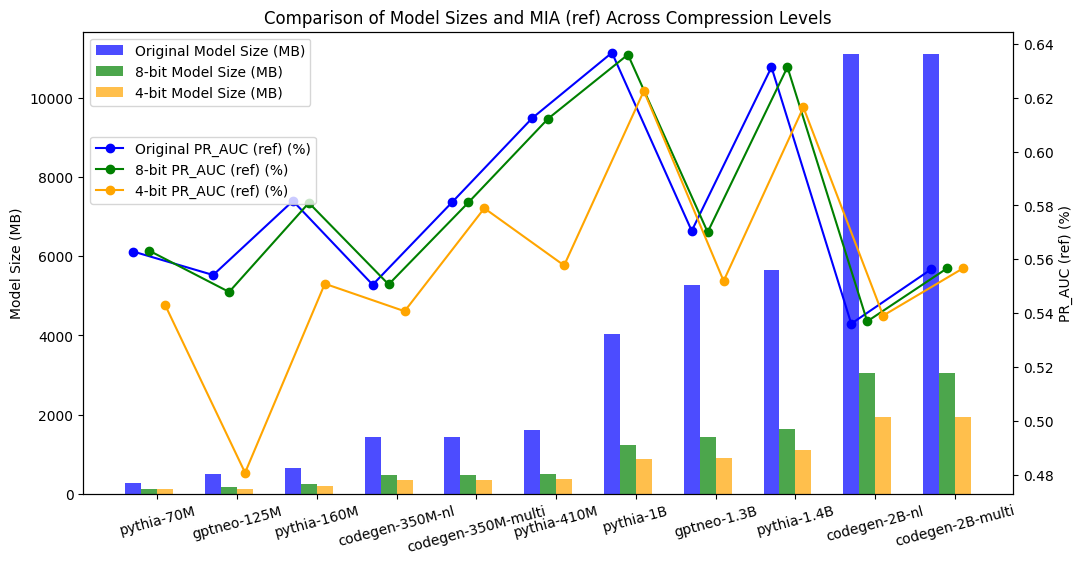

In [20]:
genGraph(df.iloc[:, [0,1,2,3]], miaName="LOSS")
genGraph(df.iloc[:, [0,1,2,4]], miaName="LOSS")
genGraph(df.iloc[:, [0,1,2,5]], miaName="min_K")
genGraph(df.iloc[:, [0,1,2,6]], miaName="min_K")
genGraph(df.iloc[:, [0,1,2,7]], miaName="zlib")
genGraph(df.iloc[:, [0,1,2,8]], miaName="zlib")
genGraph(df.iloc[:, [0,1,2,9]], miaName="ref")
genGraph(df.iloc[:, [0,1,2,10]], miaName="ref")

In [13]:
def genGraph(df, miaName):
    scoreName = df.columns[3].split(".")[0]
    # Extract unique model names
    models = df["Model"].unique()
    compressions = df["Compression"].unique()

    # Define bar width and colors
    bar_width = 0.2
    colors = ["blue", "green", "orange"]

    x = np.arange(len(models))  # X-axis positions

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot bar chart for model sizes
    for i, comp in enumerate(compressions):
        subset = df[df["Compression"] == comp]
        ax1.bar(x + i * bar_width, subset["Size (MB)"], width=bar_width, label=f"{comp} Model Size (MB)", alpha=0.7, color=colors[i])

    ax1.set_ylabel("Model Size (MB)")
    ax1.set_xticks(x + bar_width * 1.5)
    ax1.set_xticklabels(models, rotation=15)
    ax1.legend(loc="upper left")

    # Second y-axis for performance scores
    ax2 = ax1.twinx()

    # Plot line chart for performance
    for i, comp in enumerate(compressions):
        subset = df[df["Compression"] == comp]
        ax2.plot(x + i * bar_width, subset.iloc[:,3], marker="o", linestyle="-", label=f"{comp} {scoreName} ({miaName}) (%)", color=colors[i])

    ax2.set_ylabel(f"{scoreName} ({miaName}) (%)")
    ax2.set_ylim(0.54, 0.711)
    ax2.legend(loc="center left", bbox_to_anchor=(0, 0.75))

    plt.title(f"Comparison of Model Sizes and MIA ({miaName}) Across Compression Levels")
    # plt.savefig(f"./output/{scoreName}({miaName}).png", dpi=300, bbox_inches="tight")
    plt.show()
# genGraph(df.iloc[:, [0,1,2,3]], miaName="LOSS")
# genGraph(df.iloc[:, [0,1,2,4]], miaName="LOSS")
# genGraph(df.iloc[:, [0,1,2,7]], miaName="zlib")
# genGraph(df.iloc[:, [0,1,2,8]], miaName="zlib")

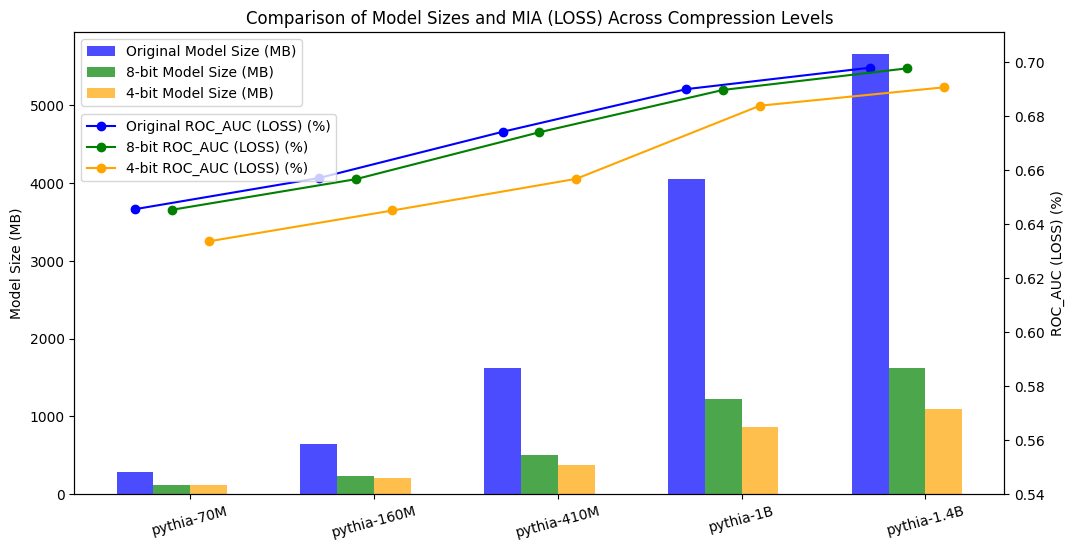

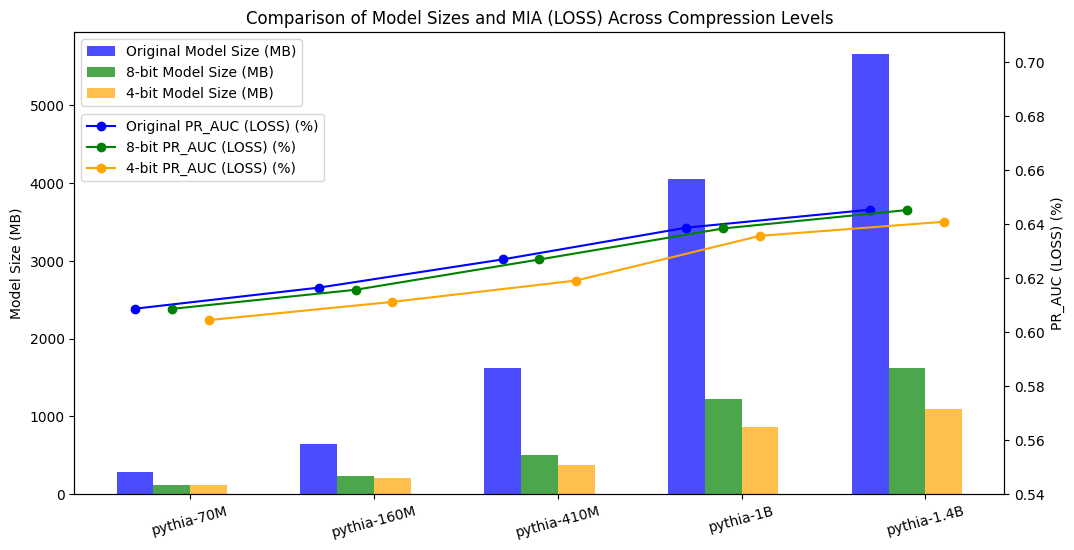

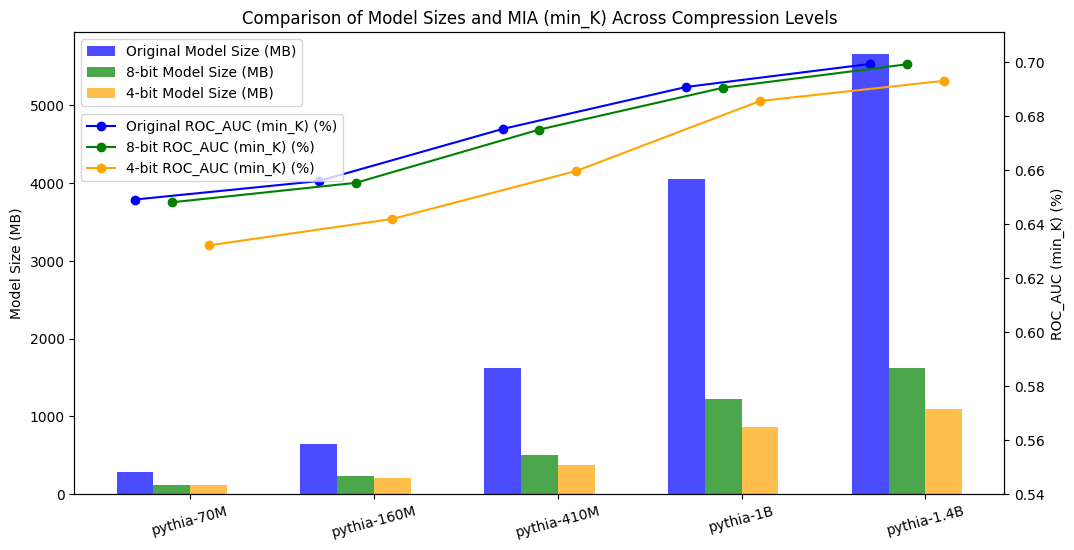

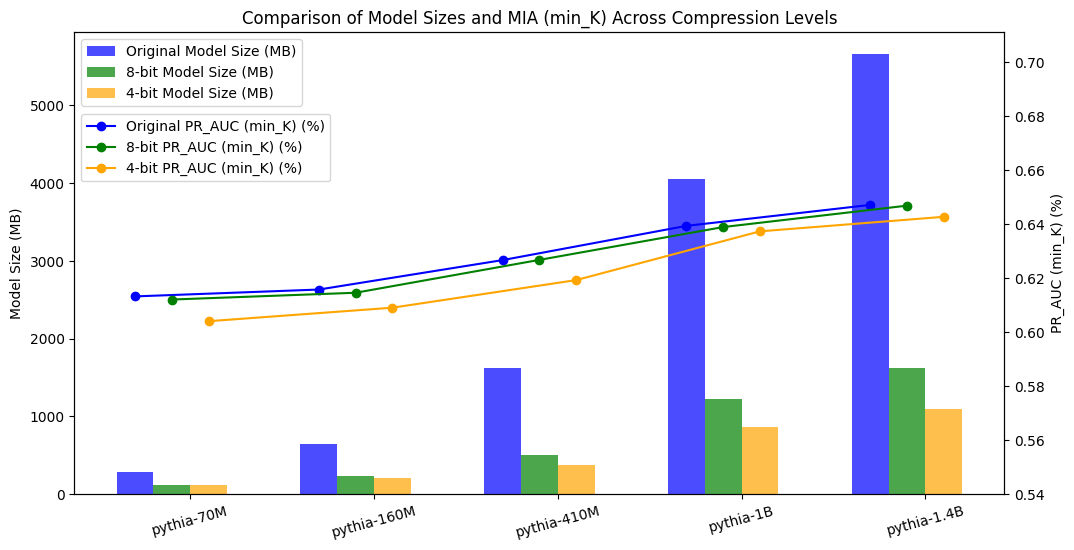

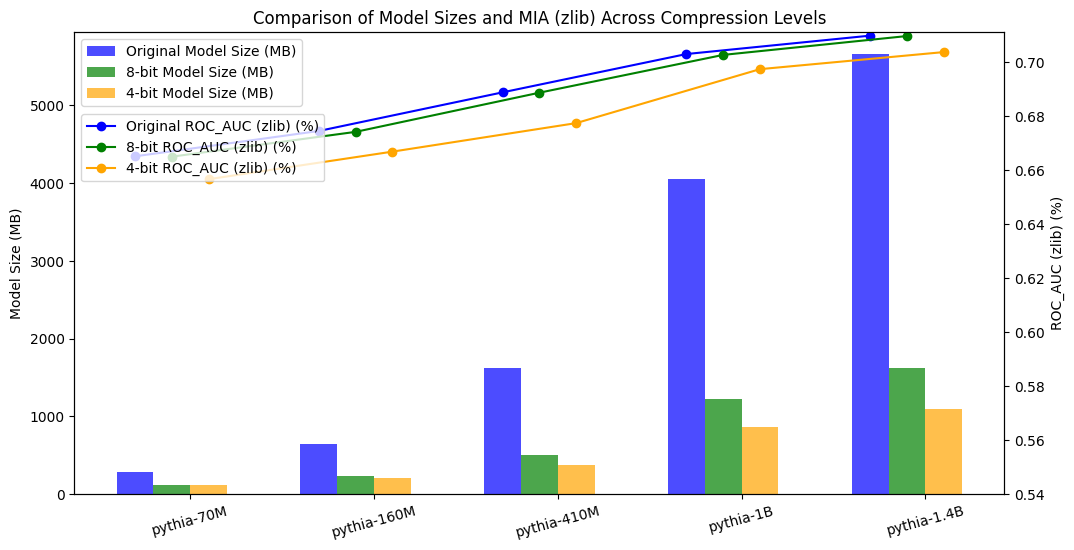

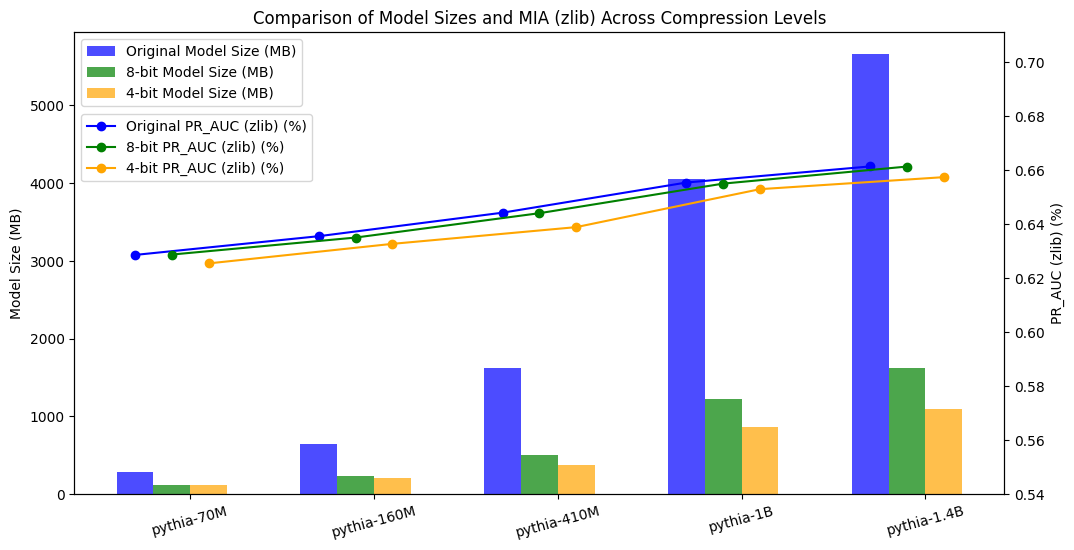

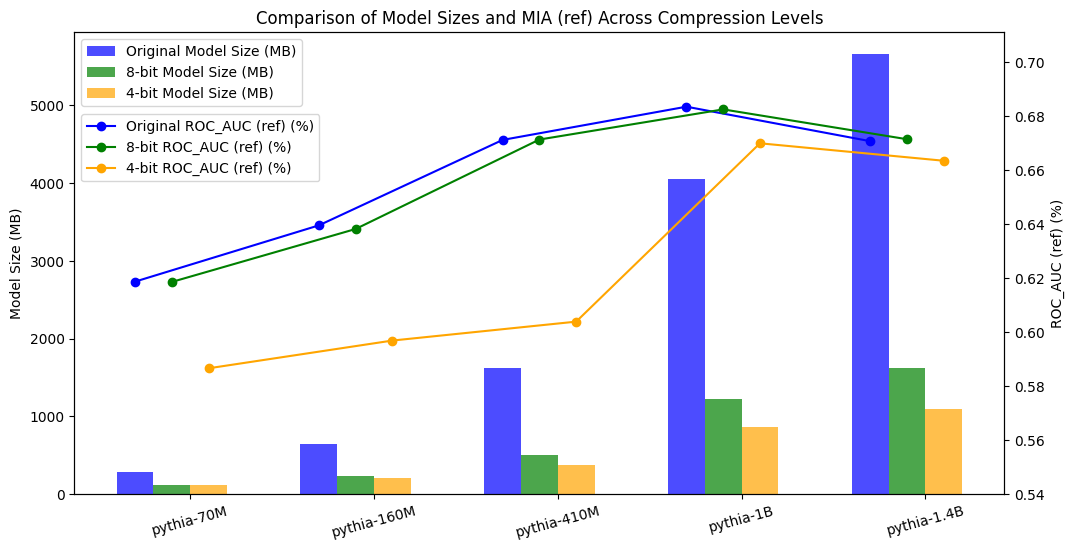

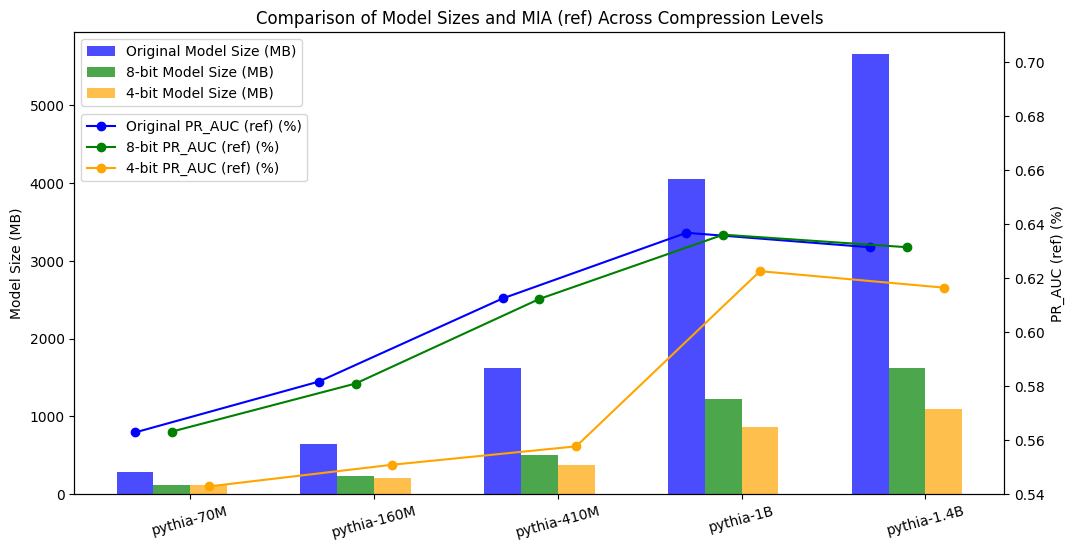

In [14]:
genGraph(df.iloc[:, [0,1,2,3]], miaName="LOSS")
genGraph(df.iloc[:, [0,1,2,4]], miaName="LOSS")
genGraph(df.iloc[:, [0,1,2,5]], miaName="min_K")
genGraph(df.iloc[:, [0,1,2,6]], miaName="min_K")
genGraph(df.iloc[:, [0,1,2,7]], miaName="zlib")
genGraph(df.iloc[:, [0,1,2,8]], miaName="zlib")
genGraph(df.iloc[:, [0,1,2,9]], miaName="ref")
genGraph(df.iloc[:, [0,1,2,10]], miaName="ref")